## Hans Alin gjorde fina plots - 2D plots ECal RecHits

Om man vill navigera sig i events.root-filer med ROOT-programmet (tips från Lene-Kristian)

denv rootbrowse runs/it_pileup/events.root

Importera och välj events-fil

Inspektera filen och se vilka unika keys som finns i den

In [1]:
import uproot
import matplotlib.pyplot as plt
import awkward as ak

events_path = "../runs/it_pileup/events.root"

file = uproot.open(events_path)
tree = file["LDMX_Events"]  # or whatever your tree is calledimport uproot

f_inspect = uproot.open(events_path)

keys = [k.split(";")[0] for k in f_inspect.keys()]          # strip ROOT cycle suffix ";1"
keys = sorted(set(keys))

print(f"Found {len(keys)} unique objects in {events_path}\n")
for k in keys:
    print(k)

print("\nBRANCHES:")
for b in tree.keys():
    print(b)

Found 2 unique objects in ../runs/it_pileup/events.root

LDMX_Events
LDMX_Run

BRANCHES:
EventHeader
EventHeader/event_number_
EventHeader/run_
EventHeader/timestamp_
EventHeader/timestamp_/timestamp_.fSec
EventHeader/timestamp_/timestamp_.fNanoSec
EventHeader/weight_
EventHeader/is_real_data_
EventHeader/int_parameters_
EventHeader/int_parameters_/int_parameters_.first
EventHeader/int_parameters_/int_parameters_.second
EventHeader/float_parameters_
EventHeader/float_parameters_/float_parameters_.first
EventHeader/float_parameters_/float_parameters_.second
EventHeader/string_parameters_
EventHeader/string_parameters_/string_parameters_.first
EventHeader/string_parameters_/string_parameters_.second
SimParticles_ecal_pn
SimParticles_ecal_pn/SimParticles_ecal_pn.first
SimParticles_ecal_pn/SimParticles_ecal_pn.second.energy_
SimParticles_ecal_pn/SimParticles_ecal_pn.second.pdg_id_
SimParticles_ecal_pn/SimParticles_ecal_pn.second.gen_status_
SimParticles_ecal_pn/SimParticles_ecal_pn.second.

Hitta EcalRecHits i x, y, z

Hitta energierna för de olika hits som finns och plotta i histogram

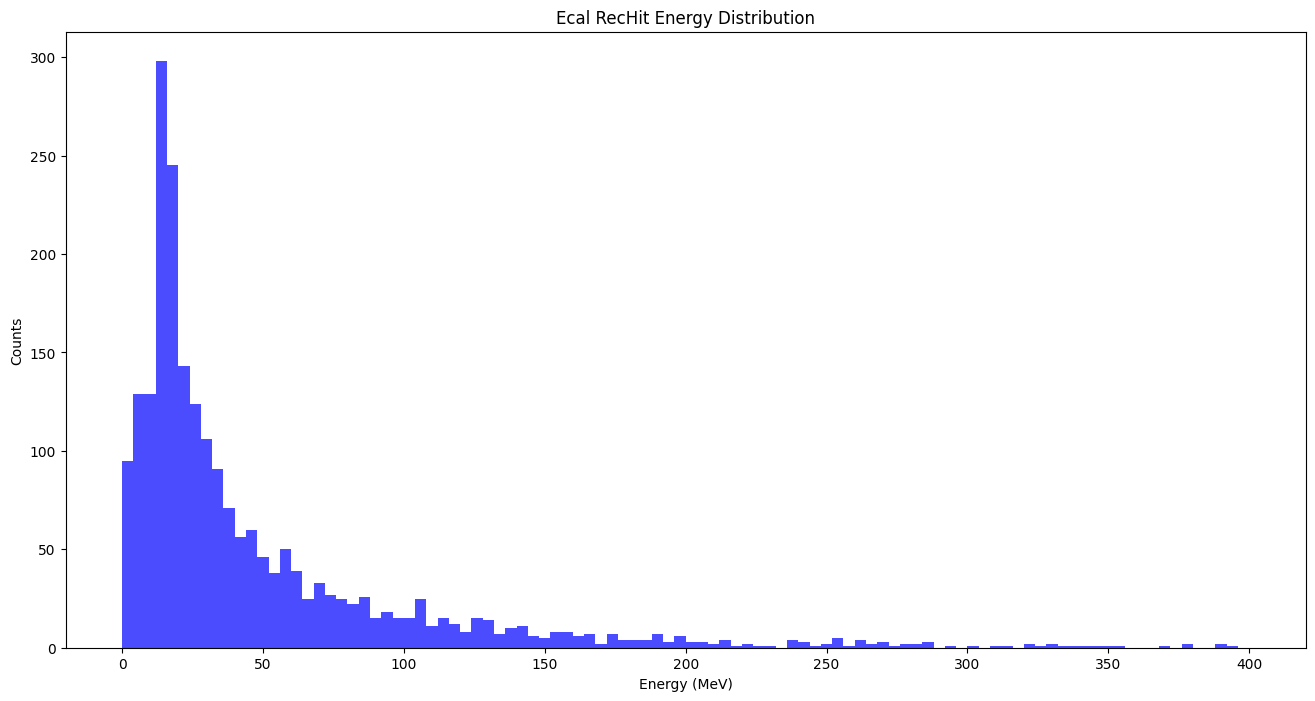

In [2]:
# To array x, y ,z and energy of Ecal RecHits
ecal_y = tree["EcalRecHits_overlay/EcalRecHits_overlay.ypos_"].array()
ecal_x = tree["EcalRecHits_overlay/EcalRecHits_overlay.xpos_"].array()
ecal_z = tree["EcalRecHits_overlay/EcalRecHits_overlay.zpos_"].array()
ecal_energy = tree["EcalRecHits_overlay/EcalRecHits_overlay.energy_"].array()

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.hist(ak.flatten(ecal_energy), bins=100, alpha=0.7, color='blue', range=[0,400])
ax.set_title("Ecal RecHit Energy Distribution")
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Counts")
plt.savefig("figures/ecal_energy.png", dpi=300)
#plt.close()

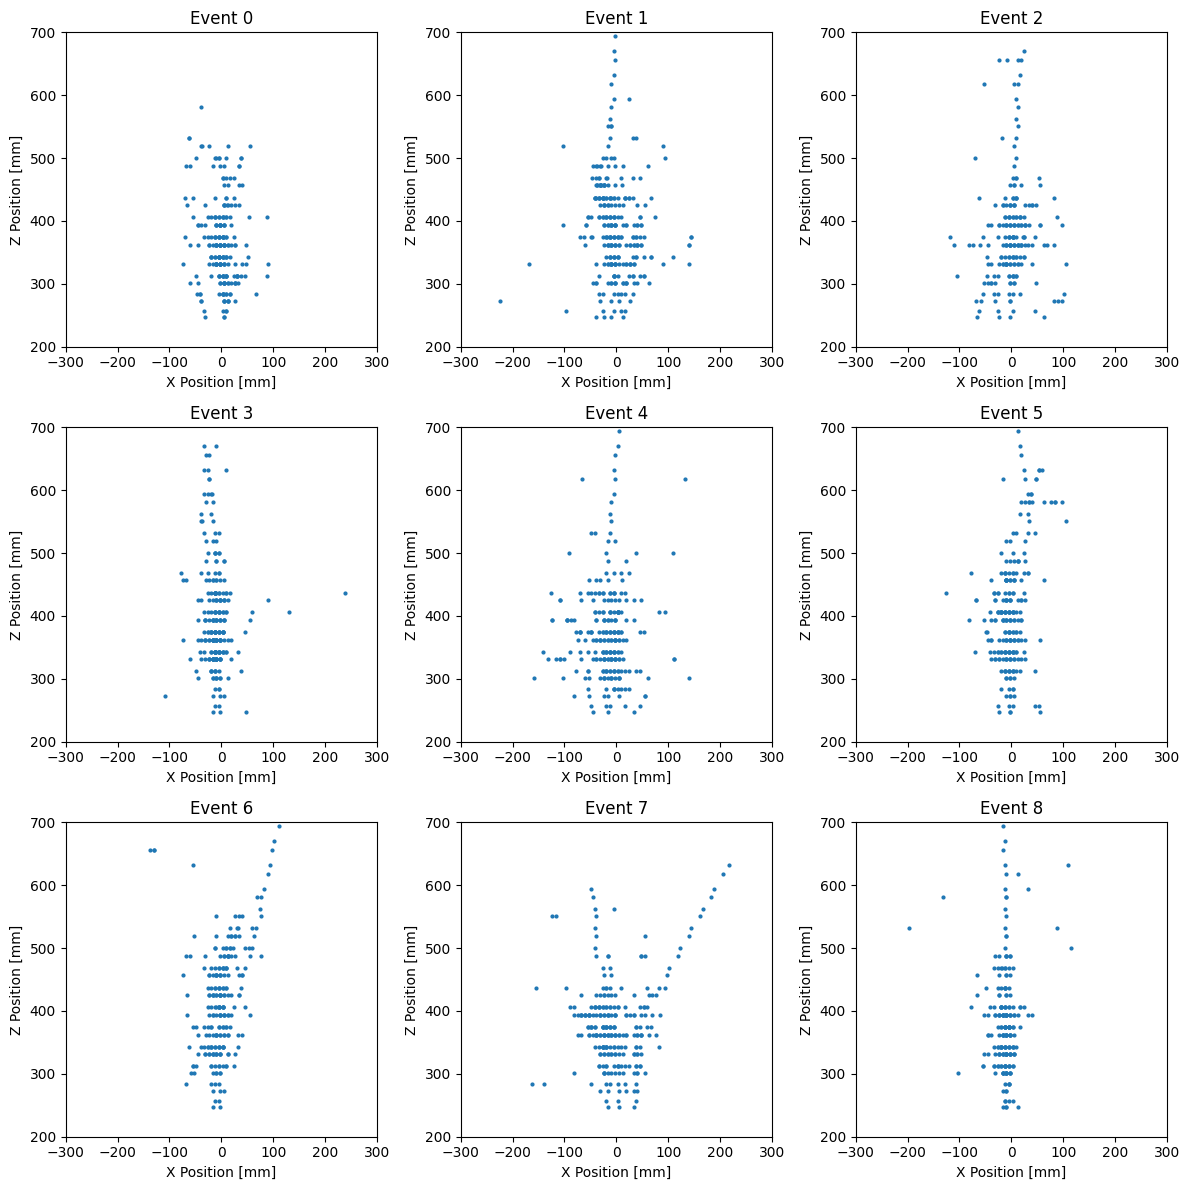

In [3]:
# Scatter plots of x vs z for up to first 9 events (3x3 grid)

rows, columns = 3, 3
nplots = rows * columns
nevents = len(ecal_x)
nshow = min(nplots, nevents)

fig, ax = plt.subplots(rows, columns, figsize=(12, 12))
ax = ax.flatten()

for index in range(nshow):
    ax[index].scatter(ecal_x[index], ecal_z[index], s=4)
    ax[index].set_title(f"Event {index}")
    ax[index].set_xlabel("X Position [mm]")
    ax[index].set_ylabel("Z Position [mm]")
    ax[index].set_xlim(-300, 300)
    ax[index].set_ylim(200, 700)

# turn off unused panels if fewer than 9 events
for index in range(nshow, nplots):
    ax[index].axis("off")

plt.tight_layout()
plt.savefig("figures/ecal_x_z_hits_3x3.png", dpi=300)
plt.show()

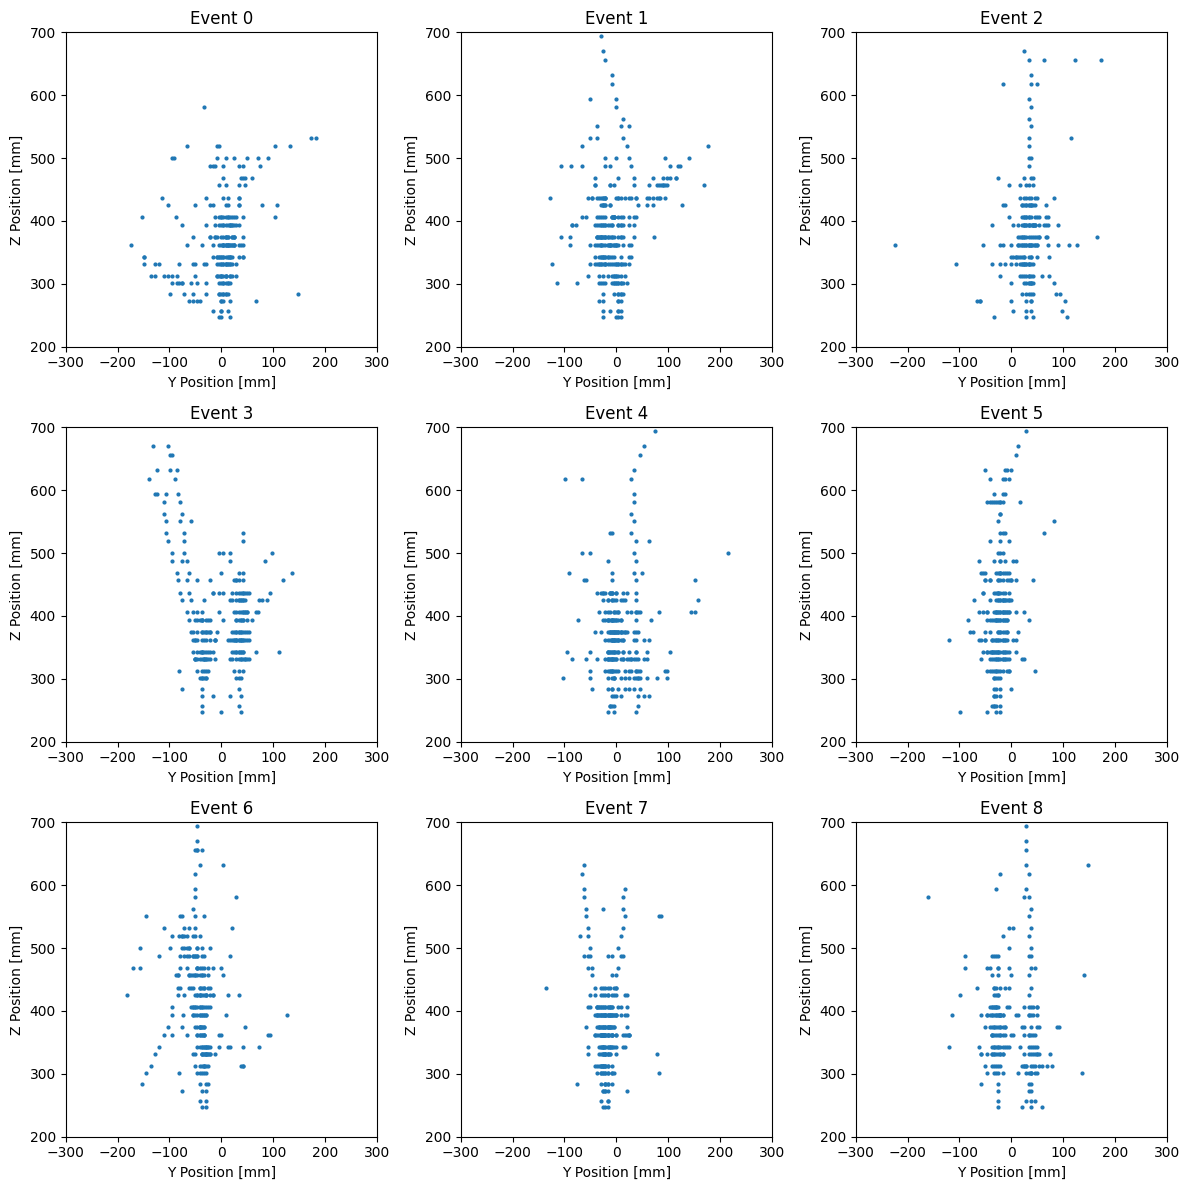

In [4]:
# Scatter plots of y vs z for up to first 9 events (3x3 grid)

rows, columns = 3, 3
nplots = rows * columns
nevents = len(ecal_y)
nshow = min(nplots, nevents)

fig, ax = plt.subplots(rows, columns, figsize=(12, 12))
ax = ax.flatten()

for index in range(nshow):
    ax[index].scatter(ecal_y[index], ecal_z[index], s=4)
    ax[index].set_title(f"Event {index}")
    ax[index].set_xlabel("Y Position [mm]")
    ax[index].set_ylabel("Z Position [mm]")
    ax[index].set_xlim(-300, 300)
    ax[index].set_ylim(200, 700)

# turn off unused panels
for index in range(nshow, nplots):
    ax[index].axis("off")

plt.tight_layout()
plt.savefig("figures/ecal_y_z_hits_3x3.png", dpi=300)
plt.show()

### 3D plot

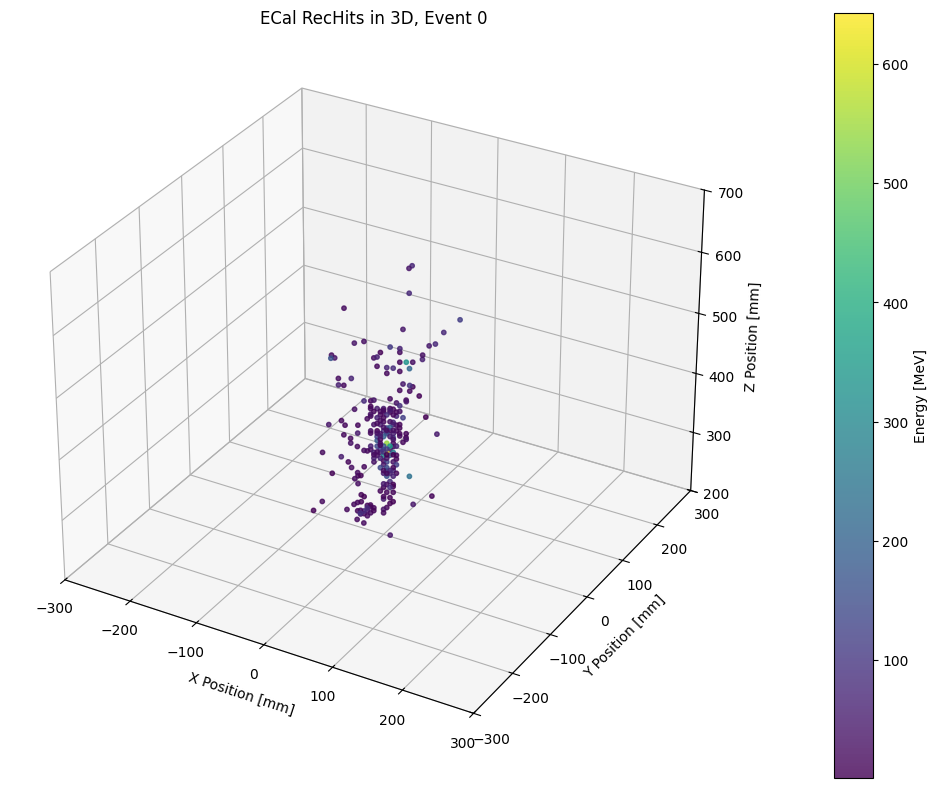

In [5]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
import awkward as ak
import matplotlib.pyplot as plt

event_idx = 0

# convert one event to regular numpy arrays
x = ak.to_numpy(ecal_x[event_idx])
y = ak.to_numpy(ecal_y[event_idx])
z = ak.to_numpy(ecal_z[event_idx])
e = ak.to_numpy(ecal_energy[event_idx])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(x, y, z, c=e, s=10, alpha=0.8)

ax.set_title(f"ECal RecHits in 3D, Event {event_idx}")
ax.set_xlabel("X Position [mm]")
ax.set_ylabel("Y Position [mm]")
ax.set_zlabel("Z Position [mm]")

ax.set_xlim(-300, 300)
ax.set_ylim(-300, 300)
ax.set_zlim(200, 700)

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Energy [MeV]")

plt.tight_layout()
plt.savefig("figures/ecal_hits_3d_event0.png", dpi=300)
plt.show()

### Interactive 3D

In [6]:
import plotly.graph_objects as go

event_idx = 0

x = ak.to_numpy(ecal_x[event_idx])
y = ak.to_numpy(ecal_y[event_idx])
z = ak.to_numpy(ecal_z[event_idx])
e = ak.to_numpy(ecal_energy[event_idx])

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode="markers",
            marker=dict(
                size=3,
                color=e,
                colorscale="Viridis",
                colorbar=dict(title="Energy [MeV]"),
                opacity=0.8,
            ),
        )
    ]
)

fig.update_layout(
    title=f"ECal RecHits 3D (Event {event_idx})",
    scene=dict(
        xaxis_title="X [mm]",
        yaxis_title="Y [mm]",
        zaxis_title="Z [mm]",
        xaxis=dict(range=[-300, 300]),
        yaxis=dict(range=[-300, 300]),
        zaxis=dict(range=[200, 700]),
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()

In [8]:
int(10e3)

10000